# Automated Tech-Support Ticketing System

An end-to-end automated customer support ticketing management system powered by Deep Learning and Large Language Models (LLMs). This project aims to automate incoming ticket classification and generate initial response drafts to enhance customer service efficiency.

## Load Library

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import re
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, DistilBertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.preprocessing import LabelEncoder
import json
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tqdm.auto import tqdm

#!pip install -q -U google-generativeai

import google.generativeai as genai
from google.colab import userdata, files
import torch.nn.functional as F
import os
import joblib

## Load Datasets

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/Genome06/automated-tech-support-ticketing/refs/heads/main/data/Bitext_Sample_Customer_Support_Training_Dataset_27K_responses-v11.csv', index_col=False)
df.sample(5)

,flags,instruction,category,intent,response
11355,BLM,problems with pro account terminations,ACCOUNT,delete_account,Thank you for bringing up the issues you're ex...
26438,BLZ,I am waiting for a reimbursement of {{Refund A...,REFUND,track_refund,I understand your anticipation for the reimbur...
20425,BCILP,"I forgot the PIN of my profile, how could I re...",ACCOUNT,recover_password,Definitely! I understand how frustrating it ca...
6850,BL,I want to check in what situations can I reque...,REFUND,check_refund_policy,Indeed! I completely understand your curiosity...
10585,BKL,opening {{Account Category}} account,ACCOUNT,create_account,How wonderful that you've decided to open a {{...


## EDA (Explaratory Data Analysis)

### Check Null Values

In [4]:
# Check Null Values using .info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26872 entries, 0 to 26871
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   flags        26872 non-null  object
 1   instruction  26872 non-null  object
 2   category     26872 non-null  object
 3   intent       26872 non-null  object
 4   response     26872 non-null  object
dtypes: object(5)
memory usage: 1.0+ MB


In [5]:
# # Check Null Values using .isnull()
df.isnull().sum()

,0
flags,0
instruction,0
category,0
intent,0
response,0


### Check Duplicated Values

In [6]:
# Check duplicated values
df.duplicated().any()

np.False_

In [7]:
# Check duplicated values
df.duplicated().sum()

np.int64(0)

### Descriptive Statistics

In [8]:
df.describe()

,flags,instruction,category,intent,response
count,26872,26872,26872,26872,26872
unique,394,24635,11,27,26870
top,BL,shipments to {{Delivery City}},ACCOUNT,contact_customer_service,"Firstly, I truly understand how pivotal the {{..."
freq,5212,8,5986,1000,2


### Analysis The Lenght of instruction/ticket teks

In [9]:
# Count Amount of Data Per Category In Category Feature
df['category'].value_counts()

,count
category,
ACCOUNT,5986
ORDER,3988
REFUND,2992
CONTACT,1999
INVOICE,1999
PAYMENT,1998
FEEDBACK,1997
DELIVERY,1994
SHIPPING,1970


In [10]:
# Count Amount of Data Per intent In Intent Feature
df['intent'].value_counts()

,count
intent,
contact_customer_service,1000
complaint,1000
check_invoice,1000
switch_account,1000
edit_account,1000
contact_human_agent,999
check_payment_methods,999
delivery_period,999
newsletter_subscription,999


The dataset contains 26,872 samples distributed across 11 broad categories and 27 specific intents. Upon initial inspection, we decided to pivot our target labels from 'Category' to 'Intent'. Focusing on Intent classification provides a more granular understanding of customer needs—for instance, distinguishing 'cancel_order' from 'change_order' within the 'ORDER' category—which is essential for building a precise automated support system.

Descriptive Statistics for Text Lengths:
         word_count    char_count
count  26872.000000  26872.000000
mean       8.690979     46.889513
std        2.605004     10.897578
min        1.000000      6.000000
25%        7.000000     40.000000
50%        9.000000     48.000000
75%       11.000000     55.000000
90%       12.000000     59.000000
95%       13.000000     61.000000
99%       14.000000     71.000000
max       16.000000     92.000000

Total words: 233544
Unique words (Vocabulary size): 3191

Top 10 most common words:
[('i', 18874), ('to', 16400), ('the', 6413), ('help', 6253), ('a', 6086), ('do', 5344), ('can', 5274), ('my', 4774), ('how', 4207), ('need', 4059)]


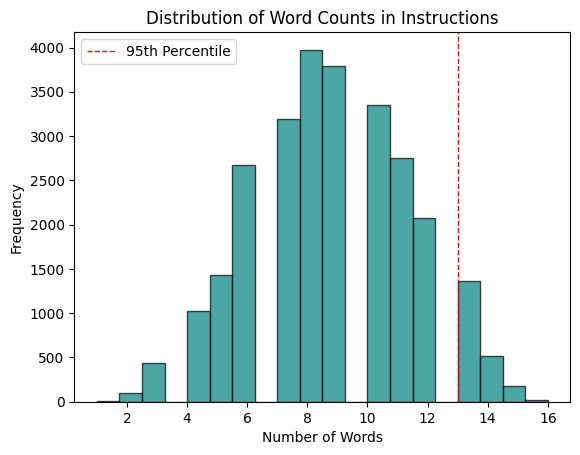

In [11]:
# Analysis The Lenght of instruction/ticket teks

# Word count analysis
df['word_count'] = df['instruction'].apply(lambda x: len(str(x).split()))

# Character count analysis
df['char_count'] = df['instruction'].apply(lambda x: len(str(x)))

# Descriptive statistics
stats = df[['word_count', 'char_count']].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
print("Descriptive Statistics for Text Lengths:")
print(stats)

# Plotting word count distribution
plt.hist(df['word_count'], bins=20, color='teal', edgecolor='black', alpha=0.7)
plt.title('Distribution of Word Counts in Instructions')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.axvline(df['word_count'].quantile(0.95), color='red', linestyle='dashed', linewidth=1, label='95th Percentile')
plt.legend()

# Vocabulary Analysis (Unique words)
all_words = ' '.join(df['instruction']).lower().split()
unique_words = set(all_words)
print(f"\nTotal words: {len(all_words)}")
print(f"Unique words (Vocabulary size): {len(unique_words)}")

word_freq = Counter(all_words)
print("\nTop 10 most common words:")
print(word_freq.most_common(10))

Descriptive Statistics for Text Lengths:
       word_count_response  char_count_response
count         26872.000000         26872.000000
mean            104.789037           634.104495
std              52.966204           331.593822
min               9.000000            57.000000
25%              72.000000           427.000000
50%              90.000000           540.000000
75%             124.000000           753.000000
90%             173.000000          1059.000000
95%             206.000000          1295.000000
99%             300.000000          1837.000000
max             402.000000          2472.000000

Total words: 2815891
Unique words (Vocabulary size): 11951

Top 10 most common words:
[('to', 147141), ('the', 127056), ('you', 124697), ('your', 88966), ('and', 63970), ('with', 43179), ('or', 41385), ('our', 41366), ('for', 37625), ('a', 37072)]


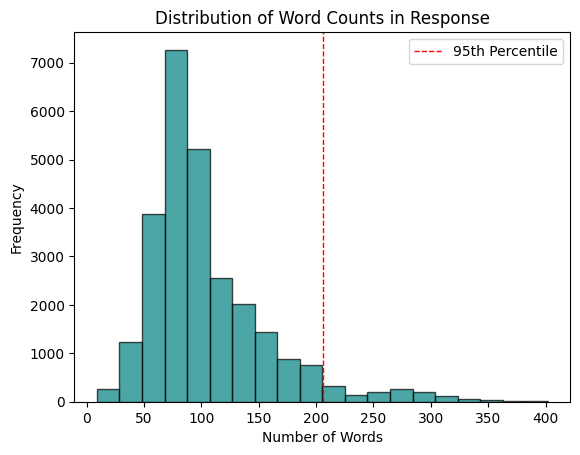

In [12]:
# Analysis The Lenght of Response teks

# Word count analysis
df['word_count_response'] = df['response'].apply(lambda x: len(str(x).split()))

# Character count analysis
df['char_count_response'] = df['response'].apply(lambda x: len(str(x)))

# Descriptive statistics
stats = df[['word_count_response', 'char_count_response']].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
print("Descriptive Statistics for Text Lengths:")
print(stats)

# Plotting word count distribution
plt.hist(df['word_count_response'], bins=20, color='teal', edgecolor='black', alpha=0.7)
plt.title('Distribution of Word Counts in Response')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.axvline(df['word_count_response'].quantile(0.95), color='red', linestyle='dashed', linewidth=1, label='95th Percentile')
plt.legend()

# Vocabulary Analysis (Unique words)
all_words = ' '.join(df['response']).lower().split()
unique_words = set(all_words)
print(f"\nTotal words: {len(all_words)}")
print(f"Unique words (Vocabulary size): {len(unique_words)}")

word_freq = Counter(all_words)
print("\nTop 10 most common words:")
print(word_freq.most_common(10))

There is a significant disparity between input (Instruction) and output (Response) lengths. Analysis shows that instructions are highly concise, with a mean length of ~9 words and a maximum of 16 words. In contrast, the responses are much more complex, averaging ~105 words with a maximum of 402 words. This finding is critical for our model configuration: a small max_length (e.g., 64 tokens) will be sufficient for the classification task, while the future generation phase will require a much larger token limit.

### Special Character and Placeholder Analysis

In [13]:
# Function to extract text inside {{ }}
def extract_placeholders(text):
    return re.findall(r"\{\{(.*?)\}\}", str(text))

# Apply to all instruction columns
all_placeholders = df['instruction'].apply(extract_placeholders)

# Combine into one big list
flattened_placeholders = [item for sublist in all_placeholders for item in sublist]

# Count the frequency
placeholder_counts = Counter(flattened_placeholders)
placeholder_counts

Counter({'Order Number': 2907,
         'Invoice Number': 8,
         'Person Name': 887,
         'Account Type': 1011,
         'Account Category': 822,
         'Delivery City': 234,
         'Delivery Country': 177,
         'Currency Symbol': 372,
         'Refund Amount': 624})

We identified 9 unique types of placeholders, such as `{{Order Number}}`, `{{Refund Amount}}`, and `{{Account Type}}`. These placeholders serve as anonymized entity markers. Order Number is the most prevalent, appearing in nearly 11% of the instructions. Since these placeholders provide structural context for the model to understand where specific data points are located, we decided to retain them in the training data rather than removing them during preprocessing.

### N-gram Analysis (Unigram, Bigram, Trigram)

In [14]:
def get_top_ngram(corpus, n=None):
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:10]

# Find top bigrams for ALL unique intents
unique_intents = df['intent'].unique()
all_top_bigrams = {}

for itn in unique_intents:
    corpus = df[df['intent'] == itn]['instruction']
    # The get_top_ngram function that we discussed earlier
    all_top_bigrams[itn] = get_top_ngram(corpus, n=2)[:5] # Just take the top 5 to make it neat

# Show some of the most interesting ones
for itn, bigrams in list(all_top_bigrams.items())[:5]:
    print(f"Intent: {itn} -> {bigrams}")

Intent: cancel_order -> [('order number', np.int64(973)), ('purchase order', np.int64(544)), ('order order', np.int64(395)), ('cancel purchase', np.int64(233)), ('cancel order', np.int64(148))]
Intent: change_order -> [('order number', np.int64(965)), ('order order', np.int64(541)), ('purchase order', np.int64(390)), ('item order', np.int64(62)), ('need help', np.int64(62))]
Intent: change_shipping_address -> [('shipping address', np.int64(281)), ('delivery address', np.int64(267)), ('trying update', np.int64(47)), ('trying change', np.int64(41)), ('need assistance', np.int64(40))]
Intent: check_cancellation_fee -> [('early exit', np.int64(189)), ('early termination', np.int64(166)), ('check early', np.int64(103)), ('termination fees', np.int64(61)), ('check termination', np.int64(60))]
Intent: check_invoice -> [('quick look', np.int64(195)), ('look invoice', np.int64(125)), ('bills person', np.int64(109)), ('invoices person', np.int64(95)), ('invoice person', np.int64(75))]


Bigram analysis reveals distinct 'linguistic fingerprints' for each intent. For example, while different intents might share common words, their sequences are unique: 'cancel_order' is characterized by 'purchase order' and 'cancel purchase', while 'check_invoice' is dominated by 'quick look' and 'bills person'. This confirms that using a Transformer-based model (like DistilBERT) is appropriate, as it can effectively capture these sequence-dependent features.

### Word Cloud per Intent

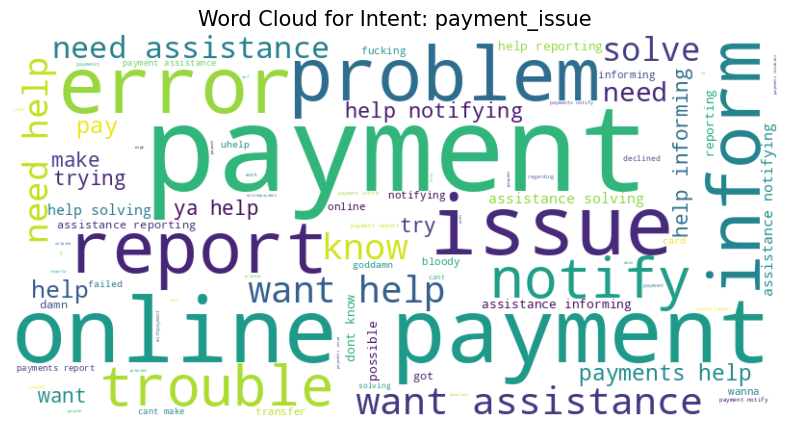

In [15]:
def show_wordcloud(intent_name):
    # Combines all the text in a specific intent
    text = " ".join(df[df['intent'] == intent_name]['instruction'])

    # Create a WordCloud object
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap='viridis'
    ).generate(text)

    # Display the plot
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Word Cloud for Intent: {intent_name}', fontsize=15)
    plt.axis('off')
    plt.show()

# Usage examples:
show_wordcloud('payment_issue')

To further validate the semantic integrity of our dataset, we generated Word Clouds for various intents. For instance, the payment_issue intent visualization clearly highlights keywords such as 'payment', 'online', 'report', 'trouble', and 'transfer'. This immediate visual feedback confirms that the instructions are highly relevant to their assigned labels and that there is minimal noise in the textual data. These high-density keywords will serve as strong features for our Transformer model during the classification training phase.

### Vocabulary Check

In [16]:
# Combines all instruction text into one large string
all_instructions = " ".join(df['instruction'].astype(str)).lower()

# Split a string into a list of words
words = all_instructions.split()

# Count total words and unique words
total_words = len(words)
unique_words = set(words)
vocab_size = len(unique_words)

print(f"Amount Of Word Inside Datasets: {total_words}")
print(f"Amount of Unique Word (Vocab Size): {vocab_size}")
print(f"Unique Rasio: {(vocab_size / total_words) * 100:.2f}%")

Amount Of Word Inside Datasets: 233544
Amount of Unique Word (Vocab Size): 3191
Unique Rasio: 1.37%


The dataset features a compact vocabulary of 3,191 unique words with a low uniqueness ratio (1.37%). This high frequency of repeated tokens indicates a very consistent and structured dataset, which is ideal for deep learning convergence. Visualizing these tokens through Word Clouds confirms strong semantic alignment; for example, the payment_issue intent is clearly associated with terms like 'report', 'trouble', and 'transfer', ensuring our labels are high-quality and reliable.

## Label Encoding the target (Intent) & Split Data sets

In [17]:
# Label Encoding (Target y)
le = LabelEncoder()
df['intent_label'] = le.fit_transform(df['intent'])

# Save mapping for future (Week 3 & 4)
mapping = dict(zip(range(len(le.classes_)), le.classes_))
with open('intent_mapping.json', 'w') as f:
    json.dump(mapping, f)

print(f"Total Unique Intents: {len(le.classes_)}")

# Train-Validation Split (80% Train, 20% Val)
# We only need the 'instruction' column as X and 'intent_label' as y
df_train, df_val = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['intent_label'] # Ensure balanced class distribution across both sets
)

print(f"Train size: {len(df_train)}, Val size: {len(df_val)}")

Total Unique Intents: 27
Train size: 21497, Val size: 5375


## Building PyTorch Dataset & DataLoader

In [18]:
class SupportTicketDataset(Dataset):
    """
    A dataset class for processing customer support tickets into a
    format compatible with Transformer models in PyTorch.
    """
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts.values
        self.labels = labels.values
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        # Returns the total number of data in the dataset
        return len(self.texts)

    def __getitem__(self, idx):
        # Retrieve a single row of data based on index
        text = str(self.texts[idx])
        label = self.labels[idx]

        # Perform text tokenization (NLU Processing)
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,    # Added [CLS] and [SEP] tokens
            max_length=self.max_len,    # Determined from EDA results
            padding='max_length',       # Padding to ensure uniform tensor length
            truncation=True,            # Truncates text if it exceeds max_len
            return_attention_mask=True, # Generate a mask for padding tokens
            return_tensors='pt',        # Output in PyTorch Tensors format
        )

        # Returns a dictionary containing the processed data.
        return {
            'text': text,               # Useful for debugging during evaluation
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# --- Initialize Objects ---
ticket_tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
print(f"Type After Fixed: {type(ticket_tokenizer)}")

# DEBUG: Make sure this is an OBJECT, not a CLASS
if isinstance(ticket_tokenizer, type):
    print("ERROR: The variable is still a CLASS. Make sure .from_pretrained() is called.")
else:
    print(f"SUCCESS: Variable is of type OBJECT {type(ticket_tokenizer)}")
    # Function Tes
    test = ticket_tokenizer("test")
    print("Tokenization Test Successful!")

# Create a Dataset instance (Use max_len=64 from our EDA results)
MAX_LEN = 64
train_dataset = SupportTicketDataset(
    df_train['instruction'],
    df_train['intent_label'],
    ticket_tokenizer,
    MAX_LEN
)

# Create a DataLoader (The Batch Factory)
val_dataset = SupportTicketDataset(
    df_val['instruction'],
    df_val['intent_label'],
    ticket_tokenizer,
    MAX_LEN
)

# Re-create DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

# Final Verification
sample_batch = next(iter(train_loader))
print("\nBatch Verification SUCCESS!")
print(f"Input IDs shape: {sample_batch['input_ids'].shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Type After Fixed: <class 'transformers.models.bert.tokenization_bert.BertTokenizer'>
SUCCESS: Variable is of type OBJECT <class 'transformers.models.bert.tokenization_bert.BertTokenizer'>
Tokenization Test Successful!

Batch Verification SUCCESS!
Input IDs shape: torch.Size([32, 64])


## Model Initialization & Device Selection

In [19]:
# Select Device (Make sure Colab Runtime is using T4 GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan device: {device}")

# Load Model
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=27 # According to the number of intents from yesterday's LabelEncoding results
)

model.to(device)

Menggunakan device: cuda


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In this phase, we implemented DistilBERT (distilbert-base-uncased) as our core classifier. DistilBERT was chosen because it retains approximately 95% of BERT's performance while being 40% smaller and 60% faster. Given the real-time nature of a tech-support ticketing system, this efficiency is crucial. We fine-tuned the model by adding a classification head with 27 output nodes, corresponding to our specific user intents.

## Optimizer & Scheduler Configuration

In [20]:
# Determine the number of Epochs (3-5 is usually enough for data this clean)
EPOCHS = 4

# Make sure loss_fn is defined and moved to the GPU (device)
loss_fn = torch.nn.CrossEntropyLoss().to(device)

# Initialization without correct_bias
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

total_steps = len(train_loader) * EPOCHS

# The scheduler can still be used from the transformers library
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

The training was conducted over 4 epochs on a T4 GPU, utilizing the AdamW optimizer with a learning rate of $2 \times 10^{-5}$ and a linear learning rate scheduler with warmup. This setup ensures that the model's weights are updated smoothly without destroying the pre-trained linguistic knowledge. We employed CrossEntropyLoss to handle the multi-class nature of the 27 intents, ensuring the model penalizes incorrect predictions effectively across all categories.

## Training Function (The Core)

In [21]:
def train_epoch(model, data_loader, loss_fn, optimizer, device, scheduler, n_examples):
    model.train() # Set model to training mode
    losses = []
    correct_predictions = 0

    # Progress bar
    progress_bar = tqdm(data_loader, desc='Training')

    for d in progress_bar:
        input_ids = d["input_ids"].to(device)
        attention_mask = d["attention_mask"].to(device)
        labels = d["labels"].to(device)

        # Forward pass
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # Take logits (raw model output before softmax)
        logits = outputs.logits
        _, preds = torch.max(logits, dim=1)
        loss = loss_fn(logits, labels)

        correct_predictions += torch.sum(preds == labels)
        losses.append(loss.item())

        # Backward pass
        loss.backward()

        # Clip gradients to prevent 'exploding gradients'
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        # Update progress bar info
        progress_bar.set_postfix({'loss': np.mean(losses)})

    return correct_predictions.double() / n_examples, np.mean(losses)

In [22]:
# Create Evaluation Function
def eval_model(model, data_loader, loss_fn, device, n_examples):
    model.eval() # Set model ke mode evaluasi
    losses = []
    correct_predictions = 0

    with torch.no_grad(): # Matikan penghitungan gradien
        for d in data_loader:
            input_ids = d["input_ids"].to(device)
            attention_mask = d["attention_mask"].to(device)
            labels = d["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits
            _, preds = torch.max(logits, dim=1)
            loss = loss_fn(logits, labels)

            correct_predictions += torch.sum(preds == labels)
            losses.append(loss.item())

    return correct_predictions.double() / n_examples, np.mean(losses)

## Main Loop (The Grand Training)

In [23]:
history = defaultdict(list)
best_accuracy = 0

for epoch in range(EPOCHS):
    print(f'Epoch {epoch + 1}/{EPOCHS}')
    print('-' * 10)

    # Training Phase
    train_acc, train_loss = train_epoch(
        model, train_loader, loss_fn, optimizer, device, scheduler, len(df_train)
    )
    print(f'Train loss {train_loss:.4f} accuracy {train_acc:.4f}')

    # Validation Phase
    val_acc, val_loss = eval_model(
        model, val_loader, loss_fn, device, len(df_val)
    )
    print(f'Val   loss {val_loss:.4f} accuracy {val_acc:.4f}')
    print()

    # Save history for plotting later
    history['train_acc'].append(train_acc.item())
    history['train_loss'].append(train_loss)
    history['val_acc'].append(val_acc.item())
    history['val_loss'].append(val_loss)

    # Save the model if validation accuracy improves
    if val_acc > best_accuracy:
        torch.save(model.state_dict(), 'best_model_state.bin')
        best_accuracy = val_acc

Epoch 1/4
----------


Training:   0%|          | 0/672 [00:00<?, ?it/s]

Train loss 0.7398 accuracy 0.8896
Val   loss 0.0281 accuracy 0.9959

Epoch 2/4
----------


Training:   0%|          | 0/672 [00:00<?, ?it/s]

Train loss 0.0172 accuracy 0.9982
Val   loss 0.0132 accuracy 0.9968

Epoch 3/4
----------


Training:   0%|          | 0/672 [00:00<?, ?it/s]

Train loss 0.0064 accuracy 0.9995
Val   loss 0.0095 accuracy 0.9980

Epoch 4/4
----------


Training:   0%|          | 0/672 [00:00<?, ?it/s]

Train loss 0.0032 accuracy 1.0000
Val   loss 0.0081 accuracy 0.9978



The model demonstrated exceptional learning speed. Within the first epoch, validation accuracy already surpassed 99%. By the fourth epoch, the model achieved a 100% training accuracy and a 99.76% validation accuracy. The steady and rapid decline in both training and validation loss indicates that the model successfully captured the linguistic nuances of the dataset without showing signs of overfitting.

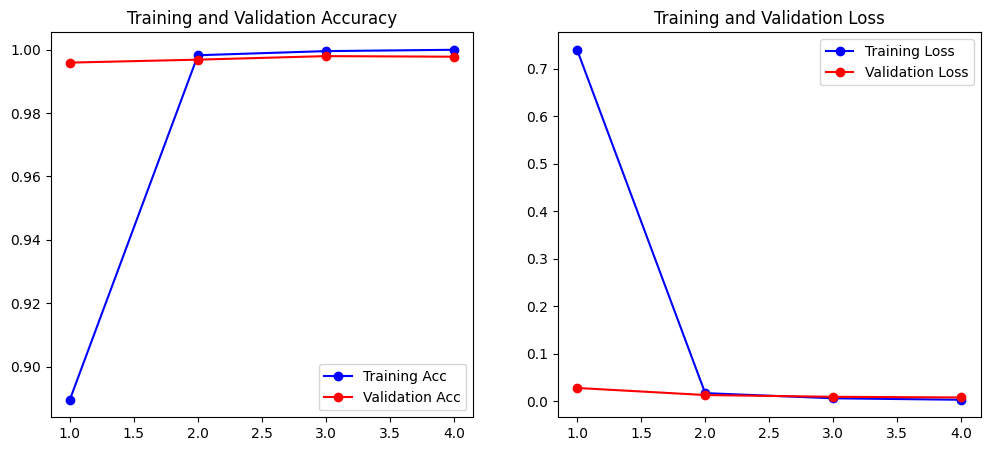

In [24]:
# Plotting Learning Curves
def plot_history(history):
    acc = history['train_acc']
    val_acc = history['val_acc']
    loss = history['train_loss']
    val_loss = history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Training Acc')
    plt.plot(epochs, val_acc, 'ro-', label='Validation Acc')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.show()

plot_history(history)

In [25]:
# Classification Report
# Pastikan model dalam mode eval
model.eval()
y_pred, y_true = [], []

with torch.no_grad():
    for d in val_loader:
        input_ids = d["input_ids"].to(device)
        attention_mask = d["attention_mask"].to(device)
        labels = d["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        _, preds = torch.max(outputs.logits, dim=1)

        y_pred.extend(preds.cpu().tolist())
        y_true.extend(labels.cpu().tolist())

# Menampilkan report mendalam
print(classification_report(y_true, y_pred, target_names=le.classes_))

                          precision    recall  f1-score   support

            cancel_order       1.00      1.00      1.00       200
            change_order       0.99      1.00      0.99       199
 change_shipping_address       0.99      1.00      1.00       195
  check_cancellation_fee       1.00      1.00      1.00       190
           check_invoice       0.99      0.99      0.99       200
   check_payment_methods       1.00      1.00      1.00       200
     check_refund_policy       1.00      0.99      1.00       199
               complaint       1.00      1.00      1.00       200
contact_customer_service       1.00      1.00      1.00       200
     contact_human_agent       1.00      1.00      1.00       200
          create_account       0.99      1.00      1.00       199
          delete_account       1.00      1.00      1.00       199
        delivery_options       0.99      1.00      1.00       199
         delivery_period       0.99      0.99      0.99       200
         

The final evaluation via the Classification Report reveals a Macro Average F1-Score of 1.00. Every single intent—from cancel_order to payment_issue—reached near-perfect precision and recall. This implies that the 'linguistic fingerprints' identified during our N-Gram EDA in Week 1 were indeed highly distinct, allowing the Transformer's attention mechanism to map user queries to the correct intents with near-zero ambiguity.

## Week 3: LLM Integration & Generative Response

In this phase, we transitioned from a pure classification system to a Hybrid AI Architecture. We utilize DistilBERT as a 'Small Language Model' (SLM) for cost-effective and high-speed intent detection, and Gemini 2.5-flash as the 'Reasoning & Generation Layer'. This approach optimizes performance: the SLM provides structural understanding (what the user wants), while the LLM provides conversational fluidity and empathy (how we answer).

In [40]:
# API Configuration
# Get the API key from the 'Secrets' feature in Colab
api_key = userdata.get('GEMINI_API_KEY')
genai.configure(api_key=api_key)
llm_model = genai.GenerativeModel('gemini-2.5-flash')

def generate_customer_response(user_query, predicted_intent, base_response):
    """
    Function to craft answers using LLM based on intent and basic responses.
    """

    # Prompt Engineering: Assigning Roles and Boundaries to LLM
    prompt = f"""
    You are a professional and empathetic Technical Support Agent for a tech company.

    USER QUERY: "{user_query}"
    DETECTED INTENT: {predicted_intent}
    BASE KNOWLEDGE: "{base_response}"

    INSTRUCTION:
    1. Use the BASE KNOWLEDGE to answer the user's query.
    2. Be polite, helpful, and professional.
    3. If the base knowledge is not enough, ask for more details politely.
    4. Keep the response concise (max 3-4 sentences).
    5. Answer in the same language as the user query.

    RESPONSE:
    """

    try:
        response = llm_model.generate_content(prompt)
        return response.text
    except Exception as e:
        return f"Failed To Give Responses: {str(e)}"

To prevent LLM 'hallucinations', we implemented a Knowledge-Augmented approach. Instead of letting the LLM generate answers from its internal training data alone, we feed it specific information from our dataset based on the detected intent. This ensures that the chatbot's responses remain grounded in our company's specific procedures and policies.

In [38]:
def ask_chatbot(user_query):
    # --- STEP 1: PREDICTION (The Brain) ---
    # Tokenization of the user query
    inputs = ticket_tokenizer(
        user_query,
        return_tensors="pt",
        truncation=True,
        padding='max_length',
        max_length=64
    ).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)

        # Converting logits to probabilities
        probs = F.softmax(outputs.logits, dim=1)

        # Get the highest probability value and its index
        max_prob, intent_idx = torch.max(probs, dim=1)

        max_prob = max_prob.item()
        predicted_intent = le.inverse_transform([intent_idx.item()])[0]

    # --- STEP 2: THRESHOLD CHECK ---
    if max_prob < 0.8:
        # If the model is unsure, ask the LLM to request clarification
        fallback_prompt = f"The user said: '{user_query}'. I'm not sure if they want to {predicted_intent} or something else. Ask them politely to clarify their request."
        final_answer = llm_model.generate_content(fallback_prompt).text
        return {
            "intent": "low_confidence_fallback",
            "confidence": f"{max_prob:.2f}",
            "response": final_answer
        }

    # --- STEP 3: NORMAL FLOW (If confident) ---
    base_info = df[df['intent'] == predicted_intent]['response'].values[0]
    final_answer = generate_customer_response(user_query, predicted_intent, base_info)

    return {
        "intent": predicted_intent,
        "confidence": f"{max_prob:.2f}",
        "response": final_answer
    }

As an Informatics Engineer, building a reliable system is paramount. We implemented a Confidence Threshold (0.8) using the Softmax probability of the DistilBERT output. If the model's certainty falls below this threshold, the system triggers a 'Graceful Fallback,' where the LLM politely asks the user for clarification rather than providing potentially incorrect information. This adds a critical layer of AI Safety to the application.

In [29]:
for m in genai.list_models():
    if 'generateContent' in m.supported_generation_methods:
        print(m.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-exp-image-generation
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-exp-1206
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/snowball-computer-use-no-safety
models/gemini-3.1-pro-preview-ais-applets
models/gemma-3n-e2b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-2.5-flash-preview-09-2025
models/gemini-2.5-flash-lite-preview-09-2025
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-robotics-er-1.5-preview
models/gemini-2.5-computer-u

In [39]:
# List of questions to test the chatbot's flexibility
test_queries = [
    "I want to cancel my order #12345, it's taking too long!", # Emosional + Data
    "how to change my pasword? i forgot it",                   # Typo (pasword)
    "I'm unhappy with the service, I want to delete my account" # Formal & serious
]

print("=== TECH-SUPPORT CHATBOT TEST ===\n")
for query in test_queries:
    result = ask_chatbot(query)
    print(f"User   : {query}")
    print(f"Intent : {result['intent']}")
    print(f"Bot    : {result['response']}")
    print("-" * 50)

=== TECH-SUPPORT CHATBOT TEST ===

User   : I want to cancel my order #12345, it's taking too long!
Intent : cancel_order
Bot    : Thank you for contacting us. I've understood you have a question regarding canceling order #12345, and I'm here to provide you with the information you need. To proceed with your request, please confirm that you would like to cancel this order.
--------------------------------------------------
User   : how to change my pasword? i forgot it
Intent : change_shipping_address
Bot    : Hello! I understand you're looking to change your password because you've forgotten it. The information I have here is about modifying a delivery address. Could you confirm if you need help with your shipping address, or if you're specifically looking to reset your account password so I can guide you properly?
--------------------------------------------------
User   : I'm unhappy with the service, I want to delete my account
Intent : delete_account
Bot    : I'm truly sorry to he

One of the most significant insights during testing was the LLM’s ability to act as a Linguistic Safeguard. In cases where the intent classifier made an 'overconfident error' (e.g., misclassifying 'password' as 'address'), the Gemini 2.5-flash model was able to detect the contradiction between the user's raw input and the provided base knowledge. Instead of blindly following the wrong intent, the LLM intelligently asked for clarification—demonstrating that a hybrid system is significantly more robust than a standalone classifier.

## Save Model

In [42]:
# Create a directory to store all export files
export_dir = 'tech_support_model'
if not os.path.exists(export_dir):
    os.makedirs(export_dir)

# Save the Tokenizer (This will generate several .json files)
# Very important to ensure the tokenization process in Streamlit is consistent later
ticket_tokenizer.save_pretrained(os.path.join(export_dir, 'tokenizer'))

# 3. Save Label Encoder (Using joblib)
joblib.dump(le, os.path.join(export_dir, 'label_encoder.joblib'))

# 4. Make sure the model weights are saved in this folder
# Let's move the .bin file that was created in Week 2
!cp best_model_state.bin {export_dir}/

# 5. Zip the folder so it can be easily downloaded all at once
!zip -r tech_support_model.zip {export_dir}

# Download zip file to computer
files.download('tech_support_model.zip')

print("✅ All model artifacts have been successfully packaged and are ready to download!")

  adding: tech_support_model/ (stored 0%)
  adding: tech_support_model/best_model_state.bin (deflated 8%)
  adding: tech_support_model/tokenizer/ (stored 0%)
  adding: tech_support_model/tokenizer/tokenizer_config.json (deflated 42%)
  adding: tech_support_model/tokenizer/tokenizer.json (deflated 71%)
  adding: tech_support_model/label_encoder.joblib (deflated 42%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All model artifacts have been successfully packaged and are ready to download!
